In [1]:
from pathlib import Path
import pandas as pd
import os
import shutil
import hashlib
import seaborn as sns
from IPython.display import display
from pytorch_grad_cam import GradCAM

In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
import sys
print(sys.executable)

/opt/anaconda3/envs/t3_project/bin/python


In [4]:
!{sys.executable} -m pip list | grep torch

torch                     2.4.1
torchvision               0.19.1


In [5]:
import torch

In [6]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

In [7]:
os.getcwd()
os.chdir("..")
os.getcwd()

'/Users/kalyanivenkateswaran/Documents/T3_Project/waste_classification'

In [8]:
BASE_DIR = Path.cwd()
META_DIR = BASE_DIR / "data" / "metadata"
file1=META_DIR/"consolidated_metatdata.csv"

In [9]:
metadata_df = pd.read_csv(file1)

In [10]:
from sklearn.model_selection import train_test_split


train_df, temp_df = train_test_split(
    metadata_df,
    test_size=0.30,          # 70 train / 30 temp
    stratify=metadata_df["stage2_label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,          # 15 / 15
    stratify=temp_df["stage2_label"],
    random_state=42
)

In [11]:
metadata_df.loc[metadata_df["filepath"].isin(train_df["filepath"]), "split"] = "train"
metadata_df.loc[metadata_df["filepath"].isin(test_df["filepath"]), "split"] = "test"
metadata_df.loc[metadata_df["filepath"].isin(val_df["filepath"]), "split"] = "val"

In [42]:
metadata_df

,filepath,stage1_label,stage2_label,source,type,split_key,split
0,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,val
1,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,train
2,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,train
3,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,train
4,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,val
...,...,...,...,...,...,...,...
67601,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,White_Glass,garbage,clean,White_Glass_clean,train
67602,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,White_Glass,garbage,clean,White_Glass_clean,train
67603,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,White_Glass,garbage,clean,White_Glass_clean,train
67604,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,White_Glass,garbage,clean,White_Glass_clean,val


In [44]:
metadata_df.loc[metadata_df['stage1_label'] == 'Organic']

,filepath,stage1_label,stage2_label,source,type,split_key,split
11111,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Organic,Organic,MendleyGCdataset,clean,Organic_clean,train
11112,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Organic,Organic,MendleyGCdataset,clean,Organic_clean,train
11113,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Organic,Organic,Tricascade,clean,Organic_clean,val
11114,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Organic,Organic,MendleyGCdataset,clean,Organic_clean,val
11115,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Organic,Organic,MendleyGCdataset,clean,Organic_clean,train
...,...,...,...,...,...,...,...
31031,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Organic,Organic,MendleyGCdataset,clean,Organic_clean,train
31032,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Organic,Organic,Tricascade,clean,Organic_clean,train
31033,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Organic,Organic,MendleyGCdataset,clean,Organic_clean,train
31034,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Organic,Organic,MendleyGCdataset,clean,Organic_clean,val


In [47]:
metadata_df.loc[metadata_df['stage1_label'] == 'Non_Organic']

,filepath,stage1_label,stage2_label,source,type,split_key,split
0,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,val
1,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,train
2,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,train
3,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,train
4,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,Non_Organic,MendleyGCdataset,clean,Non_Organic_clean,val
...,...,...,...,...,...,...,...
67601,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,White_Glass,garbage,clean,White_Glass_clean,train
67602,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,White_Glass,garbage,clean,White_Glass_clean,train
67603,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,White_Glass,garbage,clean,White_Glass_clean,train
67604,/Users/kalyanivenkateswaran/Documents/T3_Proje...,Non_Organic,White_Glass,garbage,clean,White_Glass_clean,val


### Define transforms

In [13]:
from torchvision import transforms

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [15]:
val_transform = {
    
    "default": transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
   ])
}

### Custom waste dataset to read from metadata

In [16]:
# Define custom Dataset -> this will help you load images from your csv file
from torch.utils.data import Dataset
from PIL import Image

class CustomWasteData(Dataset):
    def __init__(self, csv_df, split,label_col, transforms_dict,train=True):
        self.df = csv_df
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        
        #self.transform = transform
        self.label_col = label_col
        self.transforms_dict = transforms_dict
        self.train = train
        
        self.classes = sorted(self.df[label_col].unique())
        self.class_to_idx = {
            cls: i for i, cls in enumerate(self.classes)
        }

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["filepath"]).convert("RGB")
        label = self.class_to_idx[row[self.label_col]]
        source = row["source"]     
        type_image = row["type"]    

        if self.train:
            if row["stage1_label"] == "Organic":
               if row["dup_flag"] == 1:
                   img = self.transforms_dict["org_dup"](img)
               else:
                   img = self.transforms_dict["org_base"](img)

            else:
                img = self.transforms_dict["non_organic"](img)
        else:
            img = self.transforms_dict["default"](img)

        return img, label, source, type_image

In [17]:
# Creating datasets - Stage 1 
train_ds_stage1 = CustomWasteData(
    metadata_df,
    split="train",
    label_col="stage1_label",
    transform=train_transform
)

val_ds_stage1 = CustomWasteData(
    metadata_df,
    split="val",
    label_col="stage1_label",
    transform=val_transform
)


In [18]:
metadata_df.loc[ metadata_df['split'] == 'train','stage1_label'].value_counts()

stage1_label
Non_Organic    33377
Organic        13947
Name: count, dtype: int64

In [19]:
len(train_ds_stage1)

47324

In [20]:
# Creating datasets - Stage 2
train_ds_stage2 = CustomWasteData(
    metadata_df,
    split="train",
    label_col="stage2_label",
    transform=train_transform
)

val_ds_stage2 = CustomWasteData(
    metadata_df,
    split="val",
    label_col="stage2_label",
    transform=val_transform
)

### Data Loaders

In [21]:
from torch.utils.data import DataLoader

train_loader_s1 = DataLoader(
    train_ds_stage1,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader_s1 = DataLoader(
    val_ds_stage1,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


In [22]:
val_ds_stage1 = CustomWasteData(
    metadata_df,
    split="val",
    label_col="stage1_label",
    transform=val_transform
)

val_loader_s1 = DataLoader(
    val_ds_stage1,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


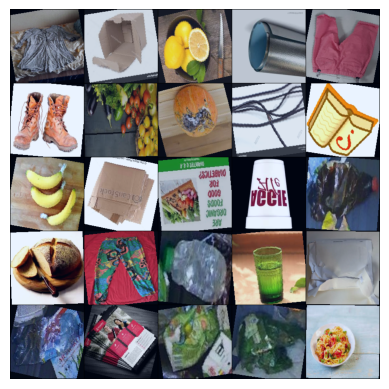

In [23]:
dataiter = iter(train_loader_s1)
images, labels, sources, type_images = next(dataiter)
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()

In [24]:
# Get one batch
images, labels, sources, type_images = next(iter(train_loader_s1))

print(images.shape)   # (batch, 3, 224, 224)

torch.Size([32, 3, 160, 160])


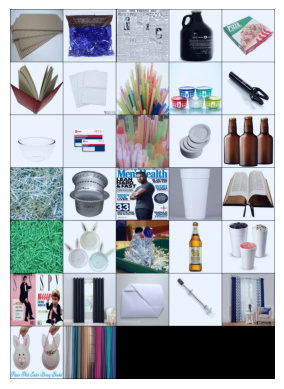

In [25]:
dataiter = iter(val_loader_s1)
images, labels , sources, type_images= next(dataiter)
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:32], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()

In [26]:
train_df["type"].value_counts()

type
clean         35898
real_world    11426
Name: count, dtype: int64

In [27]:
device = torch.device("mps")

In [28]:
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

MPS available: True
MPS built: True


/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


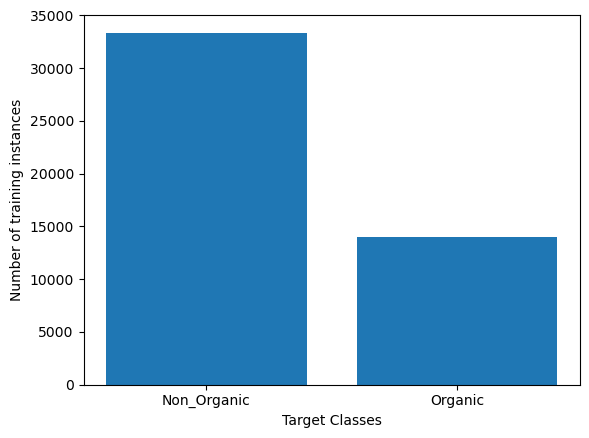

In [29]:
classes = []
for batch_idx, data in enumerate(train_loader_s1):
    x, y,a,b = data
    classes.extend(y.tolist())

unique, counts = np.unique(classes, return_counts=True)
names = list(val_ds_stage1.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")
plt.show()

### Building the CNN architecture

In [30]:
class CNN_stage1(torch.nn.Module):
    def __init__(self, num_classes, input_size=(160, 160), channels=3):
        super(CNN_stage1, self).__init__()

        self.input_size = input_size
        self.channels = channels

        # Convolutional layers
        self.conv1 = torch.nn.Conv2d(channels, 32, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = torch.nn.Conv2d(128, 256, kernel_size=3, padding=1)

        # Batch normalization layers
        self.bn1 = torch.nn.BatchNorm2d(32)
        self.bn2 = torch.nn.BatchNorm2d(64)
        self.bn3 = torch.nn.BatchNorm2d(128)
        self.bn4 = torch.nn.BatchNorm2d(256)

        # Max pooling layer
        self.pool = torch.nn.MaxPool2d(2, 2)

        # Dropout layer
        self.dropout = torch.nn.Dropout(0.5)

        # Calculate the size of the flattened features
        self._to_linear = None
        self._calculate_to_linear(input_size)

        # Fully connected layers
        self.fc1 = torch.nn.Linear(self._to_linear, 512)
        self.fc2 = torch.nn.Linear(512, num_classes)

    def _calculate_to_linear(self, input_size):
        # This function calculates the size of the flattened features
        x = torch.randn(1, self.channels, *input_size)
        self.conv_forward(x)

    def conv_forward(self, x):
        F = torch.nn.functional
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        if self._to_linear is None:
            self._to_linear = x[0].shape[0] * x[0].shape[1] * x[0].shape[2]
        return x

    def forward(self, x):
        F = torch.nn.functional
        x = self.conv_forward(x)

        # Flatten the output for the fully connected layer
        x = x.view(-1, self._to_linear)

        # Fully connected layers with ReLU and dropout
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [31]:
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device("mps")
model = CNN_stage1(2).to(device)

num_epochs = 20
learning_rate = 0.001
weight_decay = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [32]:
torch.backends.mps.is_available()

True

In [33]:
import time

start = time.time()

for i, (imgs, labels, sources, type_images) in enumerate(train_loader_s1):
    if i == 50:
        break

print("50 batches time:", time.time() - start)

/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


50 batches time: 4.224833965301514


In [34]:
epoch_time = (4.819610834121704/ 50) * 1479
epoch_time

142.56408847332

In [35]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Total number of parameters: 13498114


In [36]:
print(model)

CNN_stage1(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=25600, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)


In [37]:
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

MPS available: True
MPS built: True


In [40]:
print(next(model.parameters()).device)

mps:0


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import matthews_corrcoef

In [41]:
# Training loop
epoch_times = []
for epoch in range(num_epochs):
    start = time.time()
    model.train()
    running_loss = 0.0
    for images, labels, sources, type_images in train_loader_s1:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
    end = time.time()
    epoch_time = end - start
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1} time: {epoch_time:.2f} sec")
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader_s1):.4f}')
    print('-----------------------------')
    
total_time = sum(epoch_times)
print(f"Total training time: {total_time/60:.2f} minutes")

/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1 time: 249.64 sec
Epoch [1/20], Loss: 0.4714
-----------------------------
Epoch 2 time: 239.53 sec
Epoch [2/20], Loss: 0.3849
-----------------------------
Epoch 3 time: 238.80 sec
Epoch [3/20], Loss: 0.3593
-----------------------------
Epoch 4 time: 241.74 sec
Epoch [4/20], Loss: 0.3477
-----------------------------
Epoch 5 time: 248.44 sec
Epoch [5/20], Loss: 0.3360
-----------------------------
Epoch 6 time: 1771.27 sec
Epoch [6/20], Loss: 0.3298
-----------------------------
Epoch 7 time: 314.34 sec
Epoch [7/20], Loss: 0.3247
-----------------------------
Epoch 8 time: 247.91 sec
Epoch [8/20], Loss: 0.3203
-----------------------------
Epoch 9 time: 252.39 sec
Epoch [9/20], Loss: 0.3233
-----------------------------
Epoch 10 time: 237.64 sec
Epoch [10/20], Loss: 0.3206
-----------------------------
Epoch 11 time: 235.78 sec
Epoch [11/20], Loss: 0.3205
-----------------------------
Epoch 12 time: 238.93 sec
Epoch [12/20], Loss: 0.3165
-----------------------------
Epoch 13 

In [ ]:
# Validation
model.eval()
all_predictions = []
all_labels = []
start = time.time()
with torch.no_grad():
    for images, labels, sources, type_images in val_loader_s1:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end = time.time()
num_images= len(val_loader_s1.dataset)
avg_time = (end - start) / num_images
throughput = num_images / (end - start)

print(f"Inference time per image: {avg_time*1000:.2f} ms")
print(f"Throughput: {throughput:.2f} images/sec")

# Calculate metrics
accuracy = 100 * sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')
balanced_acccuracy=100 * balanced_accuracy_score(all_labels, all_predictions)
mcc = matthews_corrcoef(all_labels, all_predictions)

print(f'Accuracy on test set: {accuracy:.2f}%')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Balanced Accuracy on test set: {balanced_acccuracy:.2f}%')
print(f'MCC is: {mcc:.2f}')
print('-----------------------------')

In [ ]:
cm = confusion_matrix(all_labels, all_predictions, labels=[1,0])
print(classification_report(all_labels, all_predictions))

ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix : Baseline CNN'); 
ax.xaxis.set_ticklabels(['Organic', 'Non-Organic']); ax.yaxis.set_ticklabels(['Organic', 'Non-Organic'])

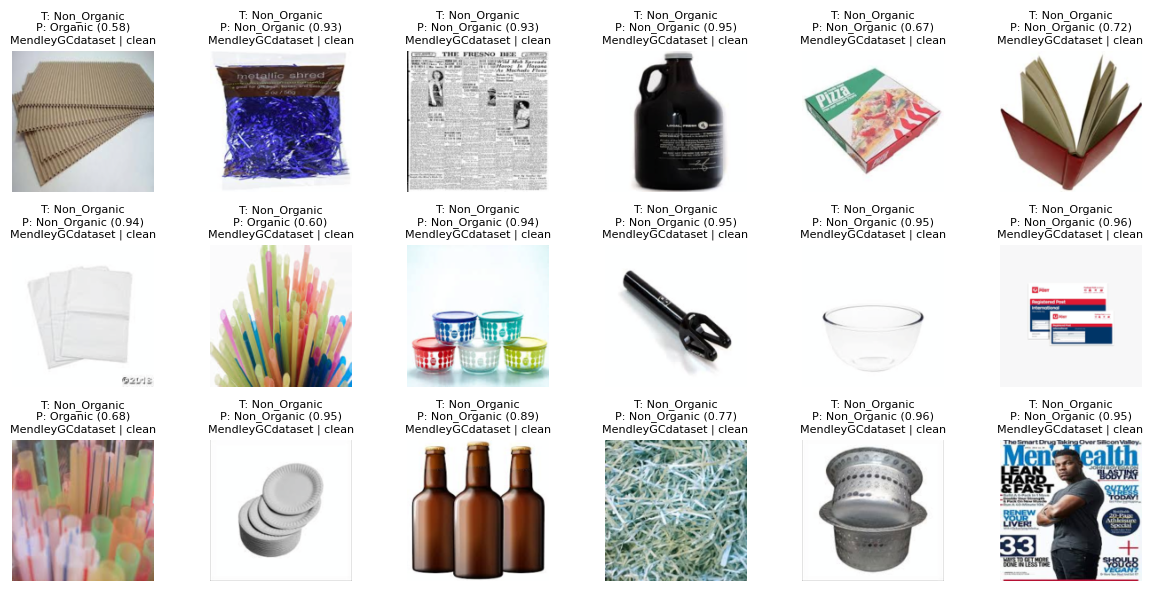

In [70]:
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    img = img.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)

    return img
    
images, labels, sources, type_images = next(iter(val_loader_s1))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

    probs = torch.softmax(outputs, dim=1)
    confs, preds = torch.max(probs, dim=1)

class_names = val_ds_stage1.classes

fig, axes = plt.subplots(3, 6, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):

    img = denormalize(images[i])
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    conf = confs[i].item()

    src = sources[i]
    type_image = type_images[i]

    ax.imshow(img)
    ax.set_title(
        f"T: {true_label}\nP: {pred_label} ({conf:.2f})\n"
        f"{src} | {type_image}",fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [73]:
print(model)

CNN_stage1(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=25600, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)


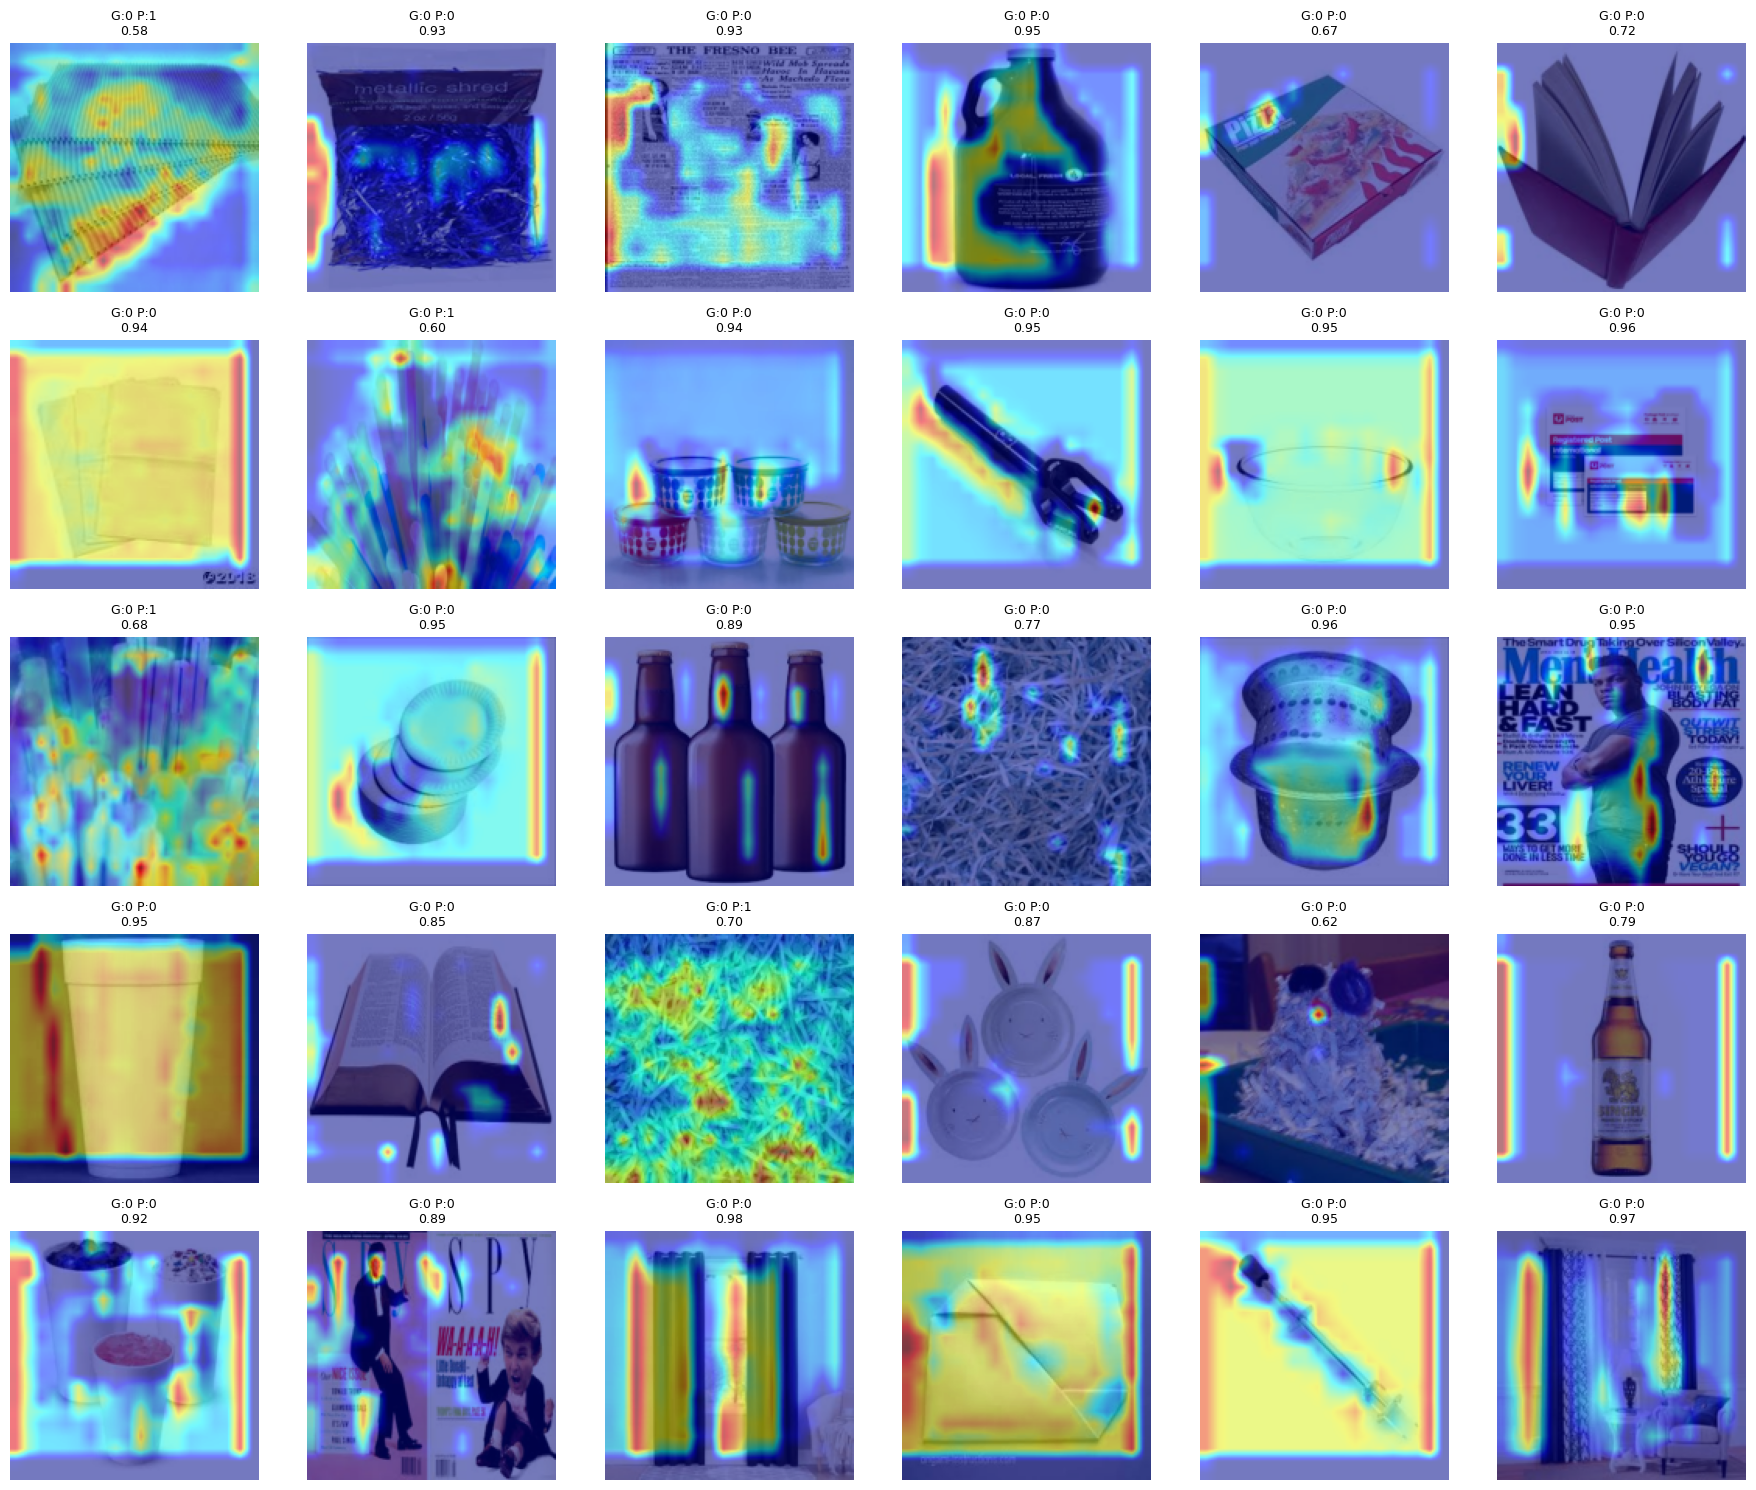

In [74]:
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("mps")

model.to(device)
model.eval()

target_layers = [model.conv4]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# ---- Get ONE validation batch ----
images, labels, sources, type_images = next(iter(val_loader_s1))

images = images.to(device)

# Forward pass
outputs = model(images)
probs = torch.softmax(outputs, dim=1)
preds = torch.argmax(probs, dim=1)

targets = [ClassifierOutputTarget(p.item()) for p in preds]

grayscale_cams = cam(
    input_tensor=images,
    targets=targets
)

batch_size = images.size(0)

# ---- Grid settings ----
rows = 5
cols = 6
max_images = rows * cols

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(min(max_images, images.size(0))):

    img_tensor = images[i].cpu()
    img_np = img_tensor.permute(1,2,0).numpy()

    # Normalize for display (edit if using mean/std)
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = grayscale_cams[i]

    visualization = show_cam_on_image(
        img_np,
        heatmap,
        use_rgb=True
    )

    plt.subplot(rows, cols, i + 1)
    plt.imshow(visualization)

    gt = labels[i].item()
    pred = preds[i].item()
    conf = probs[i][pred].item()

    plt.title(f"G:{gt} P:{pred}\n{conf:.2f}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [77]:
cm = confusion_matrix(all_labels, all_predictions, labels=[1,0])
print(classification_report(all_labels, all_predictions))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      7152
           1       0.81      0.80      0.80      2989

    accuracy                           0.88     10141
   macro avg       0.86      0.86      0.86     10141
weighted avg       0.88      0.88      0.88     10141



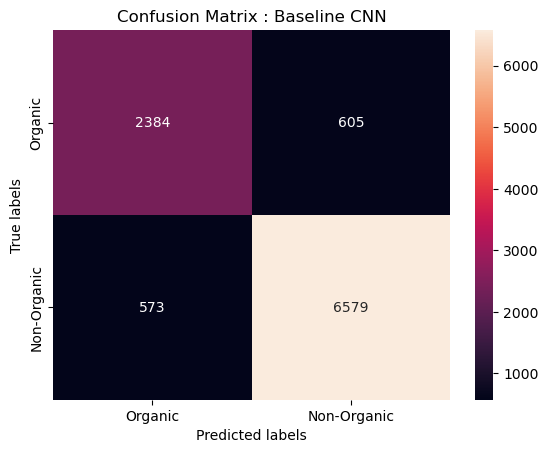

In [81]:
ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix : Baseline CNN'); 
ax.xaxis.set_ticklabels(['Organic', 'Non-Organic']); ax.yaxis.set_ticklabels(['Organic', 'Non-Organic']);

In [82]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(all_labels, all_predictions)

0.8587368589750786

In [84]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(all_labels, all_predictions)
print(mcc)

0.719737089303172


### Tuning 1  - Class weighting

In [88]:
train_ds_stage1.df['stage1_label'].values

array(['Non_Organic', 'Non_Organic', 'Non_Organic', ..., 'Non_Organic',
       'Non_Organic', 'Non_Organic'], dtype=object)

In [98]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

device = torch.device("mps")
model = CNN_stage1(2).to(device)

num_epochs = 20
learning_rate = 0.001
weight_decay = 0.01

le = LabelEncoder()
y_train = le.fit_transform(train_ds_stage1.df['stage1_label'])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [91]:
print(class_weights)

[0.7089313  1.69656557]


In [92]:
y_train

array([0, 0, 0, ..., 0, 0, 0])

In [93]:
train_ds_stage1.df['stage1_label']

0        Non_Organic
1        Non_Organic
2        Non_Organic
3        Non_Organic
4        Non_Organic
            ...     
47319    Non_Organic
47320    Non_Organic
47321    Non_Organic
47322    Non_Organic
47323    Non_Organic
Name: stage1_label, Length: 47324, dtype: object

In [95]:
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

MPS available: True
MPS built: True


In [99]:
# Training loop
epoch_times = []
for epoch in range(num_epochs):
    start = time.time()
    model.train()
    running_loss = 0.0
    for images, labels, sources, type_images in train_loader_s1:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
    end = time.time()
    epoch_time = end - start
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1} time: {epoch_time:.2f} sec")
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader_s1):.4f}')
    print('-----------------------------')
    
total_time = sum(epoch_times)
print(f"Total training time: {total_time/60:.2f} minutes")

/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20], Loss: 0.5680
Epoch [1/20]
Accuracy on test set: 84.71%
Precision: 0.8444
Recall: 0.8471
F1 Score: 0.8402
-----------------------------


/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/20], Loss: 0.4317
Epoch [2/20]
Accuracy on test set: 82.33%
Precision: 0.8515
Recall: 0.8233
F1 Score: 0.8293
-----------------------------


/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch [18/20], Loss: 0.3506
Epoch [18/20]
Accuracy on test set: 73.07%
Precision: 0.8413
Recall: 0.7307
F1 Score: 0.7419
-----------------------------


/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [19/20], Loss: 0.3492
Epoch [19/20]
Accuracy on test set: 85.25%
Precision: 0.8725
Recall: 0.8525
F1 Score: 0.8569
-----------------------------


/opt/anaconda3/envs/t3_project/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [20/20], Loss: 0.3472
Epoch [20/20]
Accuracy on test set: 86.82%
Precision: 0.8821
Recall: 0.8682
F1 Score: 0.8715
-----------------------------


In [ ]:
# Validation
model.eval()
all_predictions = []
all_labels = []
start = time.time()
with torch.no_grad():
    for images, labels, sources, type_images in val_loader_s1:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end = time.time()
num_images= len(val_loader_s1.dataset)
avg_time = (end - start) / num_images
throughput = num_images / (end - start)

print(f"Inference time per image: {avg_time*1000:.2f} ms")
print(f"Throughput: {throughput:.2f} images/sec")

# Calculate metrics
accuracy = 100 * sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')
balanced_acccuracy=100 * balanced_accuracy_score(all_labels, all_predictions)
mcc = matthews_corrcoef(all_labels, all_predictions)

print(f'Accuracy on test set: {accuracy:.2f}%')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Balanced Accuracy on test set: {balanced_acccuracy:.2f}%')
print(f'MCC is: {mcc:.2f}')
print('-----------------------------')

In [100]:
cm = confusion_matrix(all_labels, all_predictions, labels=[1,0])
print(classification_report(all_labels, all_predictions))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7152
           1       0.73      0.88      0.80      2989

    accuracy                           0.87     10141
   macro avg       0.84      0.87      0.85     10141
weighted avg       0.88      0.87      0.87     10141



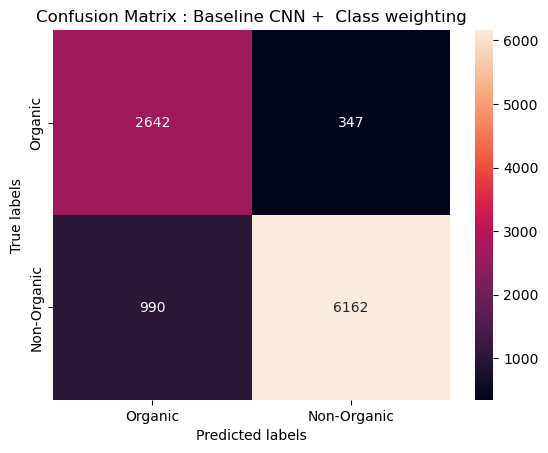

In [101]:
ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix : Baseline CNN +  Class weighting'); 
ax.xaxis.set_ticklabels(['Organic', 'Non-Organic']); ax.yaxis.set_ticklabels(['Organic', 'Non-Organic']);

In [102]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(all_labels, all_predictions)

0.8727424213166397

In [103]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(all_labels, all_predictions)
print(mcc)

0.708900809738519


In [112]:
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

In [113]:
print(precision)
print(recall)

0.8820617518792998
0.8681589586825756


In [110]:
precision = precision_score(all_labels, all_predictions, average='binary')
recall = recall_score(all_labels, all_predictions, average='binary')

In [111]:
print(precision)
print(recall)

0.7274229074889867
0.8839076614252258


In [ ]:
# 72% of predicted organics were correct
# Predicted 88% of true Organic.

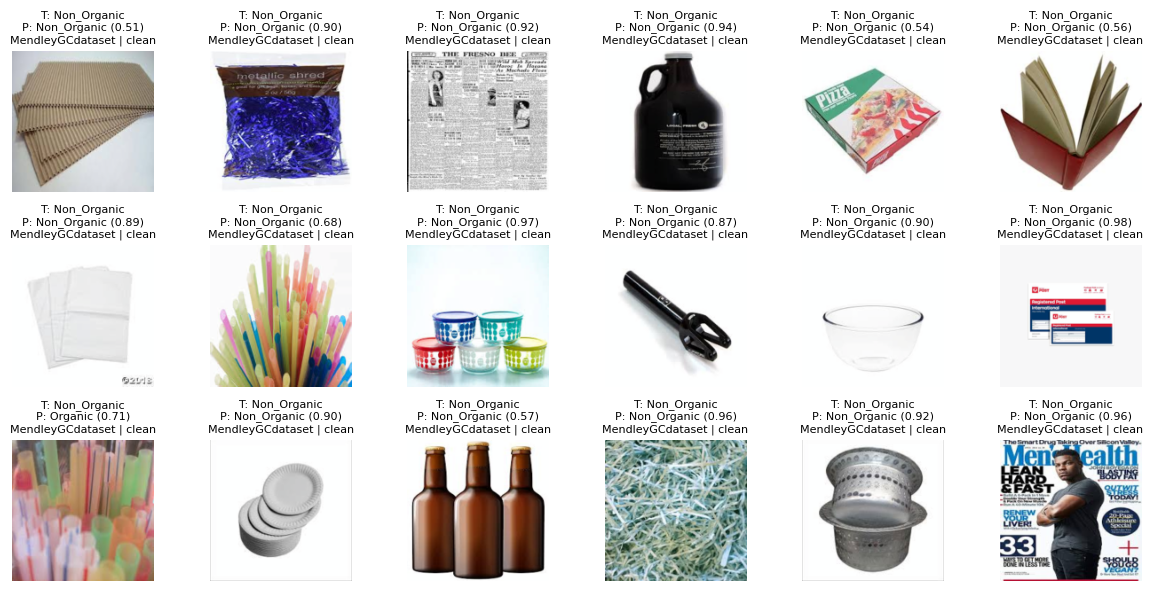

In [114]:
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    img = img.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)

    return img
    
images, labels, sources, type_images = next(iter(val_loader_s1))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

    probs = torch.softmax(outputs, dim=1)
    confs, preds = torch.max(probs, dim=1)

class_names = val_ds_stage1.classes

fig, axes = plt.subplots(3, 6, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):

    img = denormalize(images[i])
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    conf = confs[i].item()

    src = sources[i]
    type_image = type_images[i]

    ax.imshow(img)
    ax.set_title(
        f"T: {true_label}\nP: {pred_label} ({conf:.2f})\n"
        f"{src} | {type_image}",fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

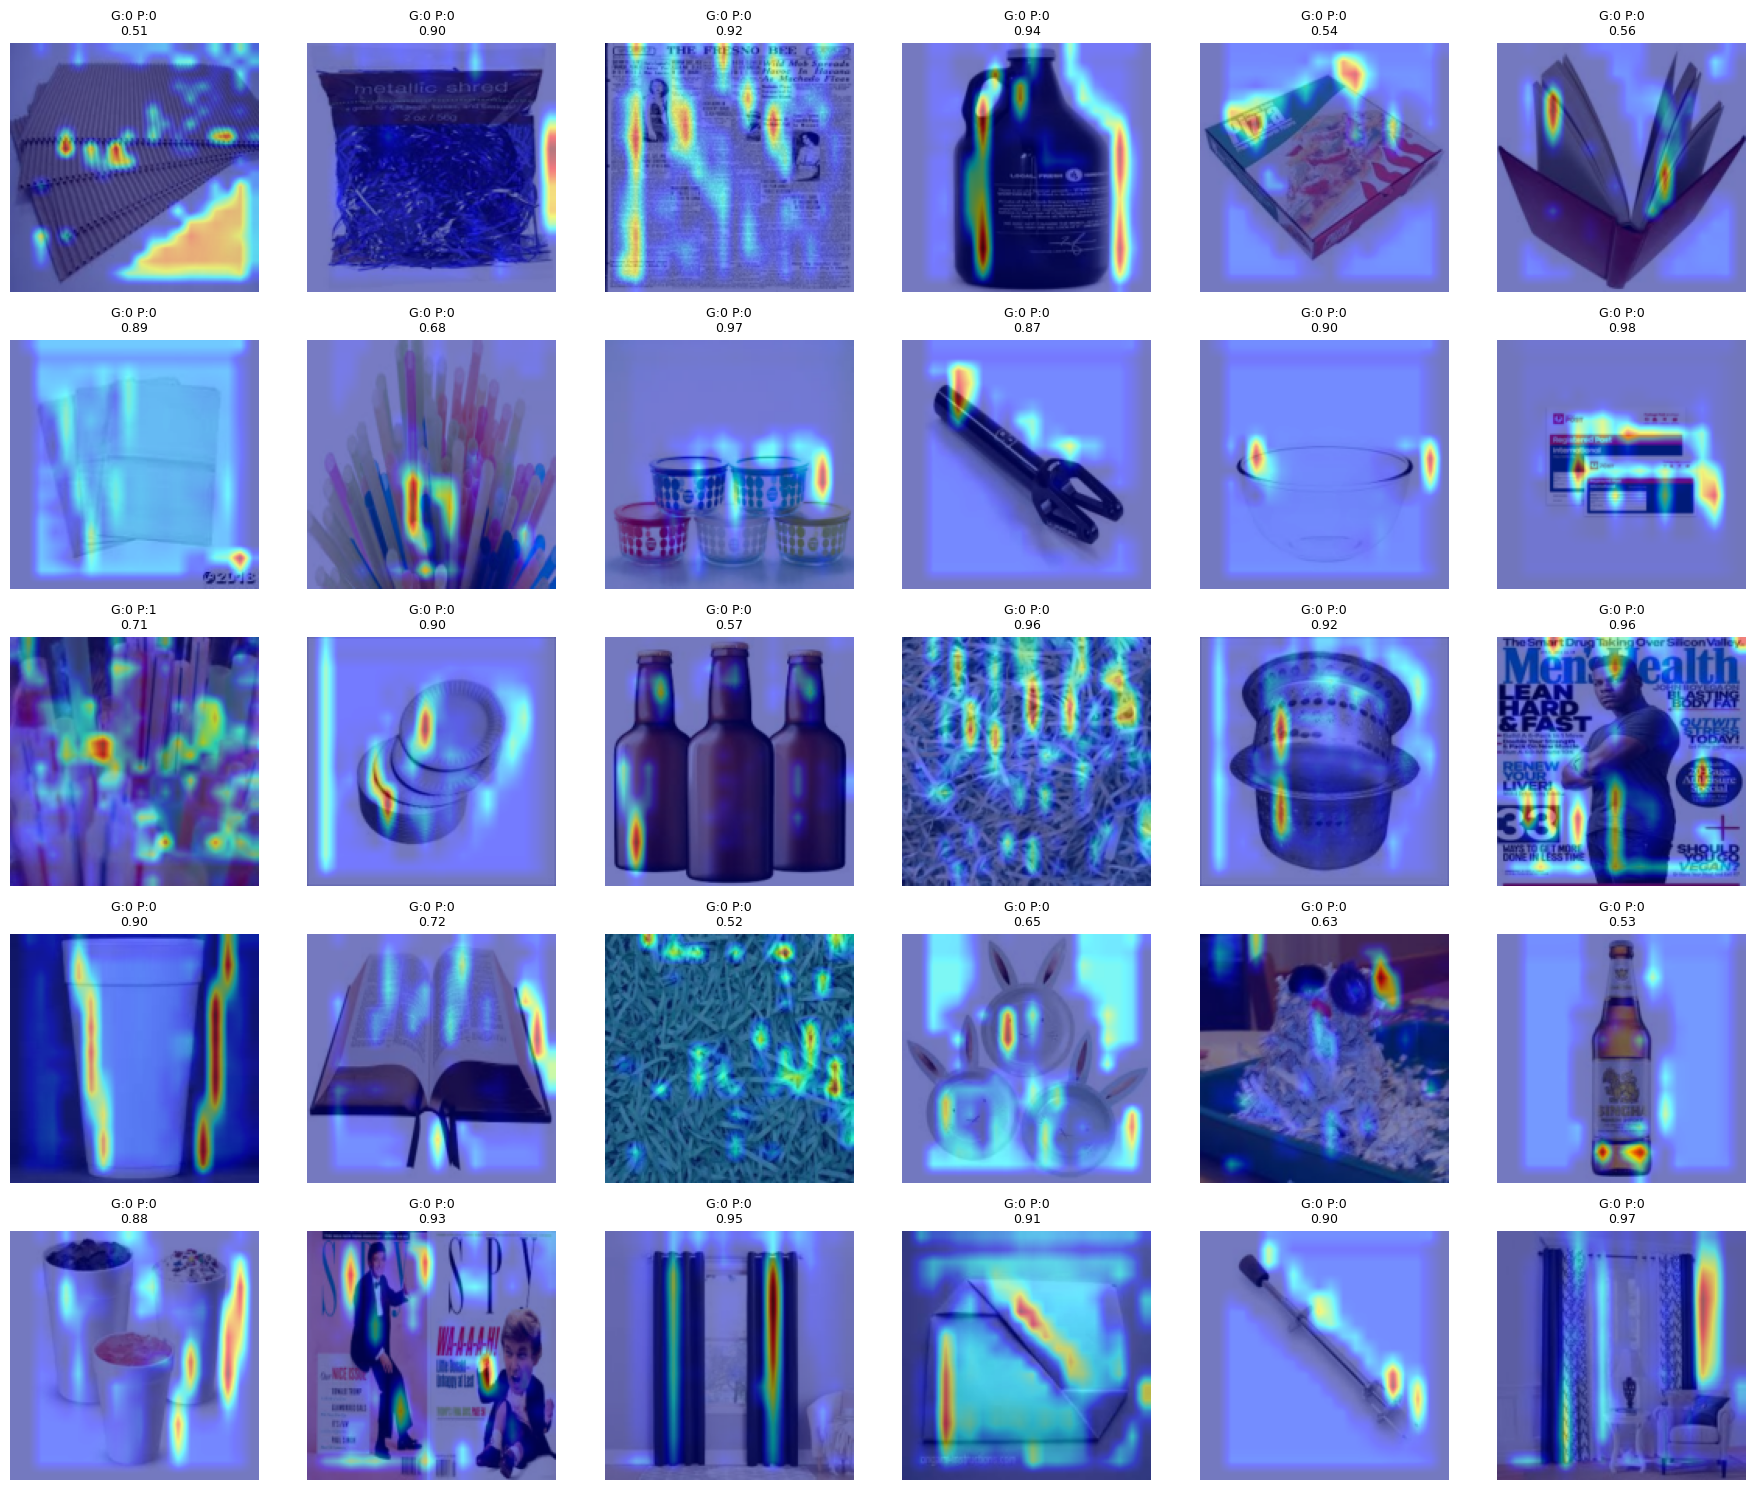

In [115]:
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("mps")

model.to(device)
model.eval()

target_layers = [model.conv4]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# ---- Get ONE validation batch ----
images, labels, sources, type_images = next(iter(val_loader_s1))

images = images.to(device)

# Forward pass
outputs = model(images)
probs = torch.softmax(outputs, dim=1)
preds = torch.argmax(probs, dim=1)

targets = [ClassifierOutputTarget(p.item()) for p in preds]

grayscale_cams = cam(
    input_tensor=images,
    targets=targets
)

batch_size = images.size(0)

# ---- Grid settings ----
rows = 5
cols = 6
max_images = rows * cols

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(min(max_images, images.size(0))):

    img_tensor = images[i].cpu()
    img_np = img_tensor.permute(1,2,0).numpy()

    # Normalize for display (edit if using mean/std)
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = grayscale_cams[i]

    visualization = show_cam_on_image(
        img_np,
        heatmap,
        use_rgb=True
    )

    plt.subplot(rows, cols, i + 1)
    plt.imshow(visualization)

    gt = labels[i].item()
    pred = preds[i].item()
    conf = probs[i][pred].item()

    plt.title(f"G:{gt} P:{pred}\n{conf:.2f}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Tuning 2  - Duplication and Targeted augmentation for Organic

In [116]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Total number of parameters: 13498114
